Looking at crossover esque strategies on the norwegian stock index instead of on individual stocks/tech 

In [13]:
import pandas as pd
import numpy as np

df_obx = pd.read_csv(r"C:\pythonlek\8sem\norne-momentum-backtest\data\processed\OBX-Historical-2000-2025.csv")
print(df_obx.head(n = 10))  

         Date   Price    Open    High     Low Vol. Change %
0  2000-01-03  149.69  149.69  149.69  149.69  NaN    1.75%
1  2000-01-04  145.27  145.27  145.27  145.27  NaN   -2.95%
2  2000-01-05  141.41  141.41  141.41  141.41  NaN   -2.66%
3  2000-01-06  141.77  141.77  141.77  141.77  NaN    0.25%
4  2000-01-07  143.79  143.79  143.79  143.79  NaN    1.42%
5  2000-01-10  147.38  147.38  147.38  147.38  NaN    2.50%
6  2000-01-11  146.07  146.07  146.07  146.07  NaN   -0.89%
7  2000-01-12  143.03  143.03  143.03  143.03  NaN   -2.08%
8  2000-01-13  145.84  145.84  145.84  145.84  NaN    1.96%
9  2000-01-14  146.52  146.52  146.52  146.52  NaN    0.47%


preproccesing 

In [37]:
import re   # regular expressions
df_obx["Date"] = pd.to_datetime(df_obx["Date"])

print(df_obx["Price"]) #Notice dtype = obj, need to convert price column into float

# after inspecting the data, noticed , separator needed to be removed

df_obx["Price"] = df_obx["Price"].astype(str).str.replace(",", "")
df_obx["Price"] = df_obx["Price"].astype(float)

print(df_obx["Vol."])
df_obx["Vol."] = df_obx["Vol."].fillna(0)
df_obx["Vol."] = df_obx["Vol."].astype(str).str.replace("M", "")
# can simply remove the Million notation 

df_obx["Vol."] = df_obx["Vol."].astype(float)



0        149.69
1        145.27
2        141.41
3        141.77
4        143.79
         ...   
6521    1575.89
6522    1577.76
6523    1580.39
6524    1587.03
6525    1597.87
Name: Price, Length: 6526, dtype: float64
0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
6521    NaN
6522    NaN
6523    NaN
6524    NaN
6525    NaN
Name: Vol., Length: 6526, dtype: object


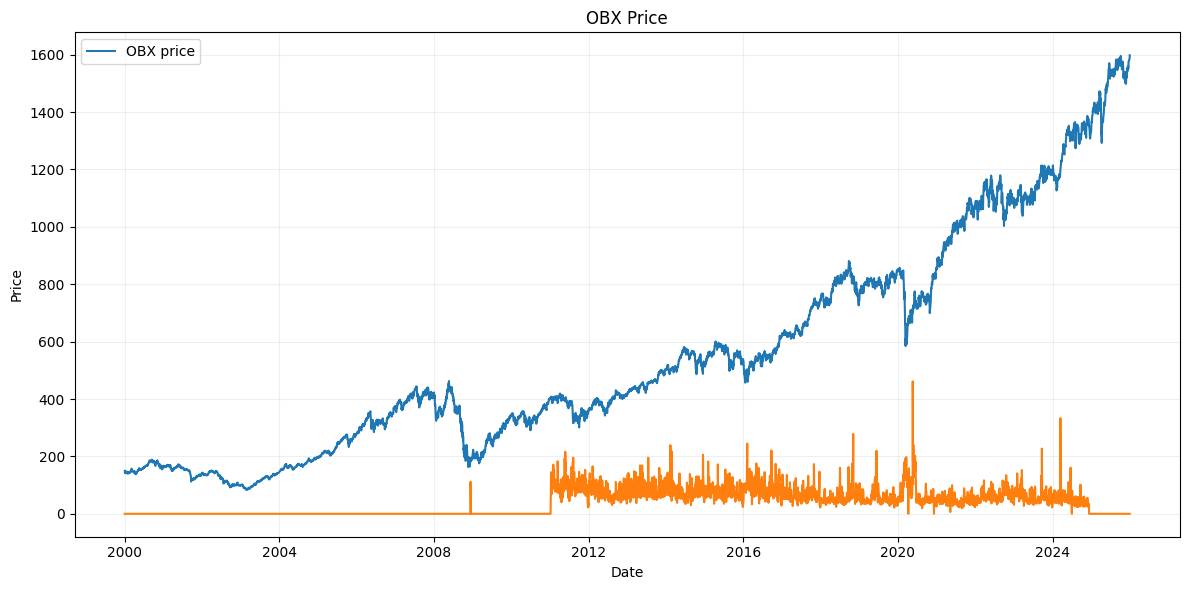

In [38]:
import matplotlib.pyplot as plt

# Plot OBX price
plt.figure(figsize=(12, 6))
plt.plot(df_obx["Date"], df_obx["Price"], label="OBX price")
plt.plot(df_obx["Date"], df_obx["Vol."])
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("OBX Price")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


short experiment looking only at price data after 2012 since thats when we start getting volatility data 

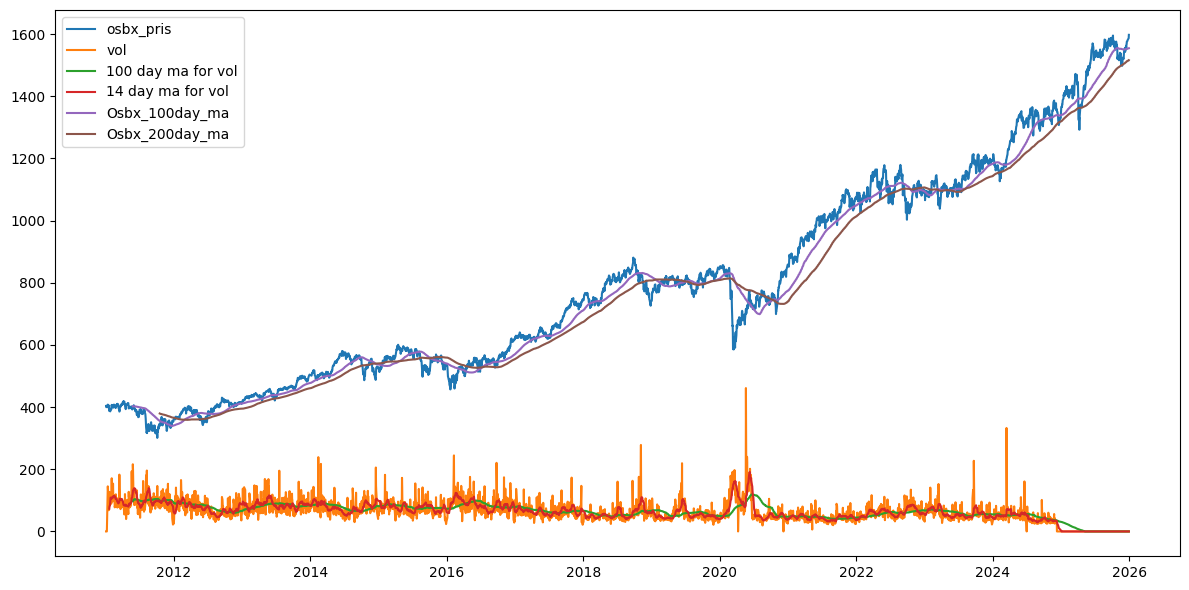

In [63]:
df_obx = df_obx[df_obx["Date"] > "2010-12-31"]
df_obx["Volatility_100dayMA"] = df_obx["Vol."].rolling(window= 100).mean()
df_obx["volatility_14dayMA"] = df_obx["Vol."].rolling(window = 14).mean()
df_obx["100dayMA"] = df_obx["Price"].rolling(window= 100).mean()
df_obx["200dayMA"] = df_obx["Price"].rolling(window = 200).mean()



plt.figure(figsize=(12, 6))
plt.plot(df_obx["Date"], df_obx["Price"], label = "osbx_pris")
plt.plot(df_obx["Date"], df_obx["Vol."], label = "vol")
plt.plot(df_obx["Date"], df_obx["Volatility_100dayMA"], label = "100 day ma for vol")
plt.plot(df_obx["Date"], df_obx["volatility_14dayMA"], label = "14 day ma for vol")
plt.plot(df_obx["Date"], df_obx["100dayMA"], label = "Osbx_100day_ma")
plt.plot(df_obx["Date"], df_obx["200dayMA"], label = "Osbx_200day_ma")
plt.tight_layout()
plt.legend()
plt.show()


combining ma-crossover strategies with vol crossover strategies

Buy & Hold total return: 295.52%
Strategy total return:  97.54%


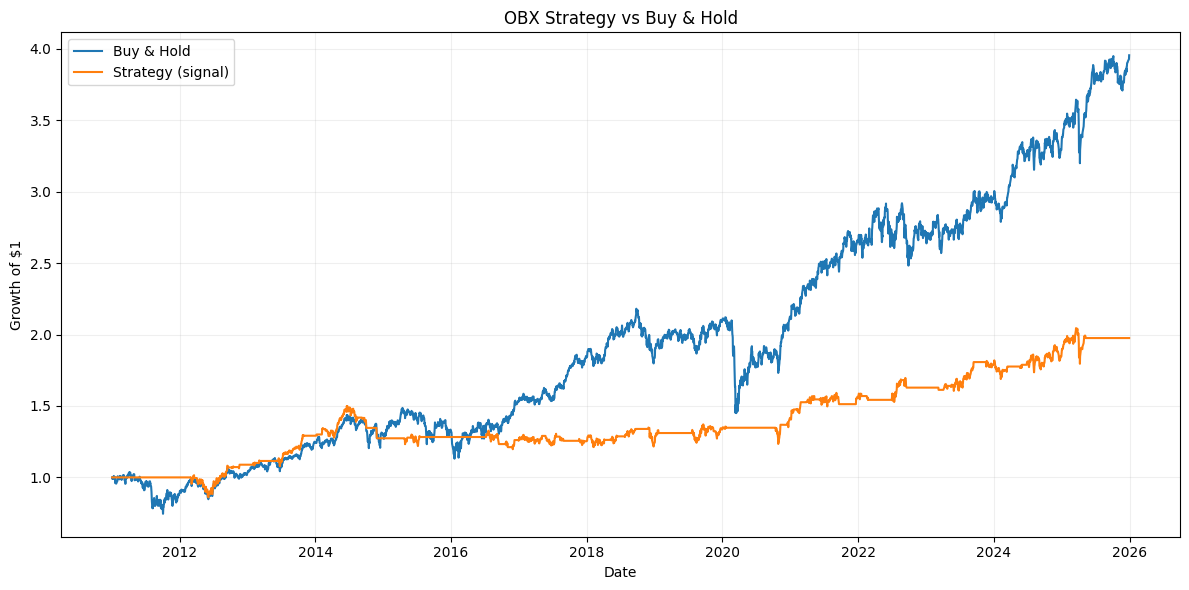

In [75]:
#very simple signal looking at double crossovers. 
df_obx["signal"] = np.where(
    (df_obx["100dayMA"] > df_obx["200dayMA"]) &
    (df_obx["Volatility_100dayMA"] > df_obx["volatility_14dayMA"]),
    1, 0
)

"""Will try to make a function which gives a score threshold based on the moving averages and the volatility"""

# 1) daily returns
df_obx = df_obx.sort_values("Date")
df_obx["ret"] = df_obx["Price"].pct_change().fillna(0)

# 2) use signal as position, shift to avoid look-ahead
df_obx["pos"] = df_obx["signal"].shift(1).fillna(1)

# 3) strategy returns
df_obx["strat_ret"] = df_obx["pos"] * df_obx["ret"]

# 4) equity curves
df_obx["buy_hold"] = (1 + df_obx["ret"]).cumprod()
df_obx["strategy"] = (1 + df_obx["strat_ret"]).cumprod()

# 5) summary stats
total_bh = df_obx["buy_hold"].iloc[-1] - 1
total_strat = df_obx["strategy"].iloc[-1] - 1

print(f"Buy & Hold total return: {total_bh:.2%}")
print(f"Strategy total return:  {total_strat:.2%}")

# Simple equity curve plot
plt.figure(figsize=(12, 6))
plt.plot(df_obx["Date"], df_obx["buy_hold"], label="Buy & Hold")
plt.plot(df_obx["Date"], df_obx["strategy"], label="Strategy (signal)")
plt.title("OBX Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
